# DBSCAN

In [1]:
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

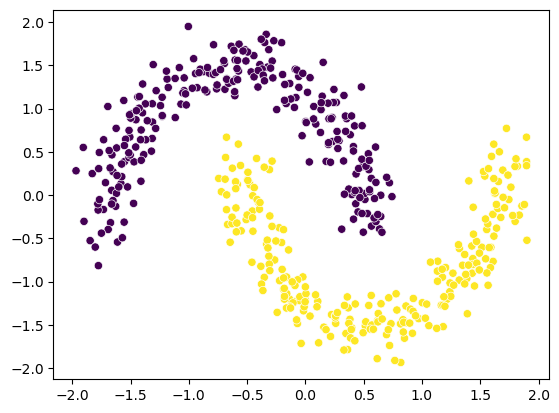

In [5]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], c=y)

<Axes: >

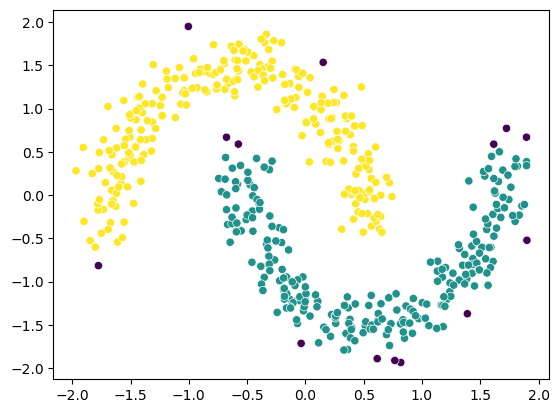

In [12]:
# DBSCAN
dbscan = DBSCAN(
    eps=0.18,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], c=labels)

# Isolation Forest

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("thyroid_dataset.csv")

In [5]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [7]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.ensemble import IsolationForest

In [10]:
clf = IsolationForest(n_estimators=200, contamination="auto", random_state=42)

In [11]:
labels = clf.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

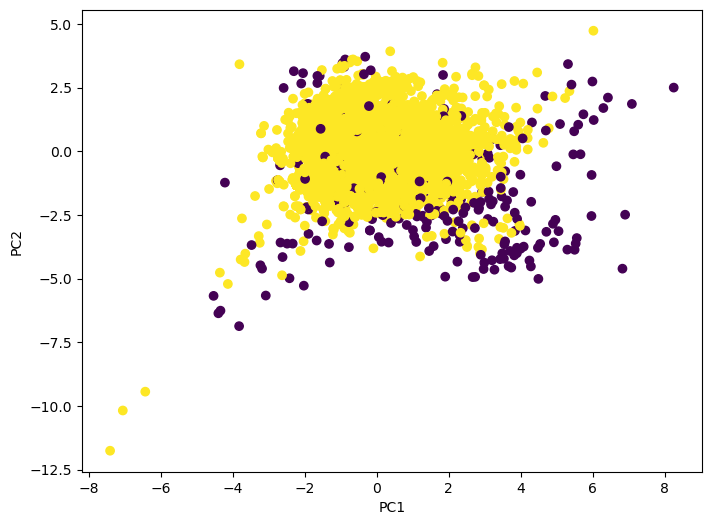

In [14]:
# Visualize data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [16]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("Outliers = ",n_outliers, ", Normal = ",n_normal)

Outliers =  270 , Normal =  6646


# LOF

In [17]:
from sklearn.neighbors import LocalOutlierFactor

Text(0, 0.5, 'PC2')

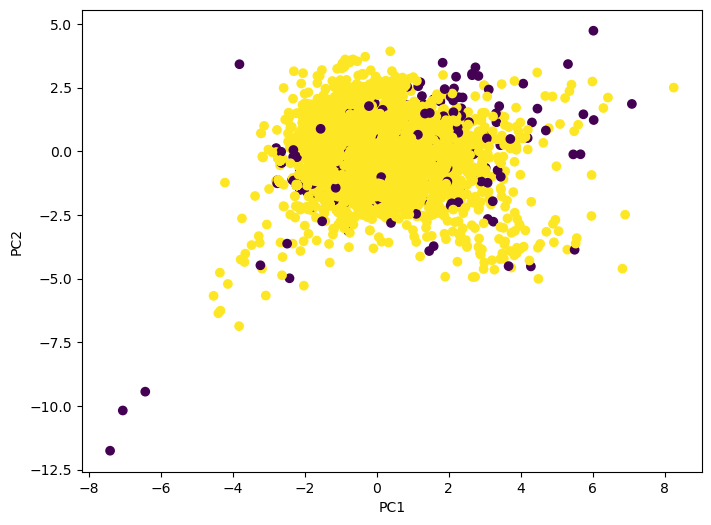

In [20]:
neighbs = LocalOutlierFactor(contamination=0.036)

labels = neighbs.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [21]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("Outliers = ",n_outliers, ", Normal = ",n_normal)

Outliers =  249 , Normal =  6667
